# 7CS033 Assignment Task 6

### Complete the following tasks.

#### You should comment on your code where appropriate. Failing to add comments may result in a mark deduction.

#### You should write any explainations in the report cell if the task explicitly asks for this or if you wish to expand upon your solution.

#### Ensure you have ran your code cell and printed any of the required outputs. If necessary you can use more than one code cell.

## Task 6.1: Download the 'Tweets' dataset from Canvas. Classify the sentiments in the dataset using six classifiers and calculate all evaluation metrics (10%).
### NOTE: If the running time is too long, you can reduce the number of samples.
### NOTE: You should comment on your code and explain what each part is doing
### NOTE: You should improve the model's performance as much as possible

In [29]:
############# WRITE THE CODE IN THIS CELL ####################
import pandas as pd
import numpy as np


# Text preprocessing
import re
import string

# Sklearn tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn import metrics #metrics


# Six classifiers
from sklearn.linear_model import LogisticRegression
#from sklearn.naive_bayes import MultinomialNB
#from sklearn.svm import LinearSVC
#from sklearn.tree import DecisionTreeClassifier
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.neighbors import KNeighborsClassifier


from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB


# Remove Stopwords
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Tweets.csv')
df.head(10)

,sentiment,tweet
0,0,Eating a gyro for breakfast at the airport. Pr...
1,1,Well .. .you fall of the 'horse' and get strai...
2,0,thanks for the responses but when is it really...
3,0,depressed.! fuuck my life!
4,1,"is LMAO, just thinkin of the 80/20 rule.....wo..."
5,1,Going out to eat neenahhhbabe(:
6,0,is saying goodbye to her momma for 4 months..
7,0,@AprilMaiya I'm not!
8,0,at work missin my brandi
9,1,@abygurl yeah i know i can't wait too


In [3]:
print(df.shape)
print(df.isna().sum())

(40000, 2)
sentiment    0
tweet        0
dtype: int64


In [4]:
# Keep only required columns
df = df[['tweet', 'sentiment']]
df

,tweet,sentiment
0,Eating a gyro for breakfast at the airport. Pr...,0
1,Well .. .you fall of the 'horse' and get strai...,1
2,thanks for the responses but when is it really...,0
3,depressed.! fuuck my life!,0
4,"is LMAO, just thinkin of the 80/20 rule.....wo...",1
...,...,...
39995,@TafiApple Awww... you retweeted me! Thanks!,1
39996,Getting some coffee before I faceplant. Guess ...,1
39997,@bernderk it could *not* be worse!,0
39998,I thought about getting a bunny...but my beagl...,1


In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"@\w+", "", text)     # remove mentions
    text = re.sub(r"#\w+", "", text)     # remove hashtags
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

# Apply cleaning
df['clean_tweet'] = df['tweet'].apply(clean_text)
df

,tweet,sentiment,clean_tweet
0,Eating a gyro for breakfast at the airport. Pr...,0,eating a gyro for breakfast at the airport pro...
1,Well .. .you fall of the 'horse' and get strai...,1,well you fall of the horse and get straight b...
2,thanks for the responses but when is it really...,0,thanks for the responses but when is it really...
3,depressed.! fuuck my life!,0,depressed fuuck my life
4,"is LMAO, just thinkin of the 80/20 rule.....wo...",1,is lmao just thinkin of the 8020 rulewonder ho...
...,...,...,...
39995,@TafiApple Awww... you retweeted me! Thanks!,1,awww you retweeted me thanks
39996,Getting some coffee before I faceplant. Guess ...,1,getting some coffee before i faceplant guess i...
39997,@bernderk it could *not* be worse!,0,it could not be worse
39998,I thought about getting a bunny...but my beagl...,1,i thought about getting a bunnybut my beagle g...


In [6]:



# Download resources (run once)
nltk.download('punkt')
nltk.download('stopwords')

# Load English stopwords
stop_words = set(stopwords.words('english'))
print(stop_words)

{'down', 'once', 'ours', 'who', 'didn', 'more', 'few', "he'd", 'him', 'can', 'd', 'his', 'how', "you'd", 'itself', 'or', 'while', 'having', 'after', "mustn't", 'those', 'theirs', 't', 'such', 'is', "i've", 'y', 'isn', "i'd", 'over', 'this', "she'll", 'shan', "isn't", 'ourselves', 'as', 'in', 'am', 'they', 'he', 'some', 'them', "they'll", 'wouldn', "wouldn't", 'should', "didn't", 'above', 'at', 'had', 'before', 'shouldn', 'the', 'your', 'doing', "we're", 'don', 'under', 'weren', 'hers', "you've", 'both', 'to', 'needn', "couldn't", "hasn't", "shouldn't", 'each', 'll', 'their', 'herself', "we'd", 'own', "needn't", 'yourself', 'between', 'hadn', "i'll", 'if', 'was', 'further', 'be', 'just', 'then', 'me', 'through', 'you', 'she', 'that', 'against', 'no', 're', 'hasn', 'wasn', "they've", 'when', "doesn't", 's', 'yours', 've', 'nor', "it'll", 'aren', 'any', 'only', 'off', 'same', "he'll", "we've", 'it', "he's", 'on', 'so', 'out', "you're", 'which', 'has', 'again', 'm', 'not', "aren't", 'i', '

[nltk_data] Downloading package punkt to /Users/oeze/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/oeze/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
#function to Tokenize and remove stopwords
def tokenize_stopwords_text(text):
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    filtered_tokens = [word for word in tokens if word not in stop_words]
    
    # Join back to string
    return " ".join(filtered_tokens)

In [8]:
#df['tokenize_stopwords'] = df['clean_tweet'].apply(clean_text)
df['tokenize_stopwords'] = df['clean_tweet'].apply(lambda x:" ".join(i for i in x.split() if i not in stop_words))
df

,tweet,sentiment,clean_tweet,tokenize_stopwords
0,Eating a gyro for breakfast at the airport. Pr...,0,eating a gyro for breakfast at the airport pro...,eating gyro breakfast airport probly gonna lun...
1,Well .. .you fall of the 'horse' and get strai...,1,well you fall of the horse and get straight b...,well fall horse get straight back probably dri...
2,thanks for the responses but when is it really...,0,thanks for the responses but when is it really...,thanks responses really lol say today say tomo...
3,depressed.! fuuck my life!,0,depressed fuuck my life,depressed fuuck life
4,"is LMAO, just thinkin of the 80/20 rule.....wo...",1,is lmao just thinkin of the 8020 rulewonder ho...,lmao thinkin 8020 rulewonder shes gonna like 2...
...,...,...,...,...
39995,@TafiApple Awww... you retweeted me! Thanks!,1,awww you retweeted me thanks,awww retweeted thanks
39996,Getting some coffee before I faceplant. Guess ...,1,getting some coffee before i faceplant guess i...,getting coffee faceplant guess wont sleeping t...
39997,@bernderk it could *not* be worse!,0,it could not be worse,could worse
39998,I thought about getting a bunny...but my beagl...,1,i thought about getting a bunnybut my beagle g...,thought getting bunnybut beagle goes berzerk c...


In [9]:
# create an input variable 'X' of the 'tokenize_stopwords' feature and target variable 'y' of the 'sentiment' feature. 
# Using the sklearn CountVectorizer() method to convert text data in X into numeric form.

X = df['tokenize_stopwords']
y = df['sentiment']

#we use countvectorizer to convert the text into a sparse matrix of counts. 
#This will enable us to train ML models on our text data as it will be represented numerically

vectorizer = CountVectorizer(token_pattern = r'\b\w+\b') 
#the token pattern tells wordvectorizer how the text should be tokenized. 
#here we specified the tokens will start at a word boundry '\b' then must contain at least 2 characters 'w+' and then ends at a word boundry '\b'
#note that set up this way words of length 1 will be ignored

X = vectorizer.fit_transform(X)

#below I convert this into a dataframe just so we can see what the count vectorizer has done
vectorized_df = pd.DataFrame(X.toarray(), columns = vectorizer.get_feature_names_out())
print(vectorized_df.columns)
vectorized_df

Index(['0', '00', '0006', '001', '0010utc', '0012', '0030', '01',
       '011203present', '02',
       ...
       'øª', 'øªø', 'øªù', 'ø³ø', 'ø³ù', 'ø¹', 'ø¹ø', 'ø¹ù', 'ù', 'ùø'],
      dtype='str', length=36814)


,0,00,0006,001,0010utc,0012,0030,01,011203present,02,...,øª,øªø,øªù,ø³ø,ø³ù,ø¹,ø¹ø,ø¹ù,ù,ùø
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
39996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
39997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
39998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
#train six classifiers to predict the sentiment of a review summary.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)


SVM = svm.SVC()
RF = RandomForestClassifier()
KNN = KNeighborsClassifier()
DT = DecisionTreeClassifier()
NB = GaussianNB()
LR = LogisticRegression()

#train the models
SVM.fit(X_train, y_train)
RF.fit(X_train, y_train)
KNN.fit(X_train, y_train)
DT.fit(X_train, y_train)
LR.fit(X_train,y_train)
NB.fit(X_train.toarray(),y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


Text(0.5, 1.0, 'KNN')

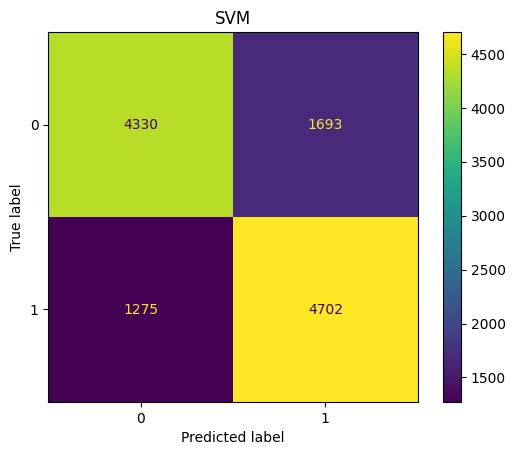

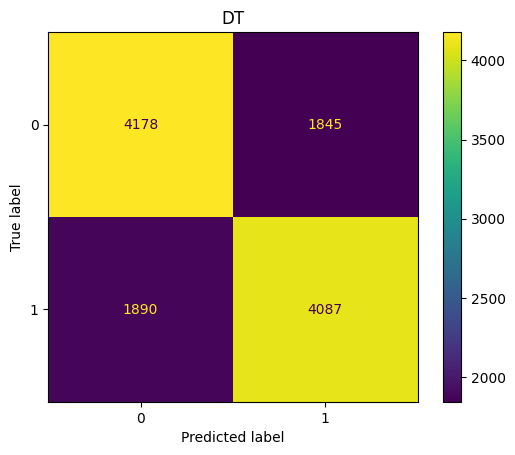

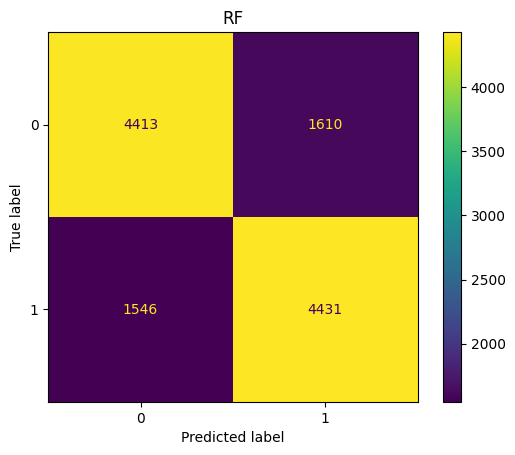

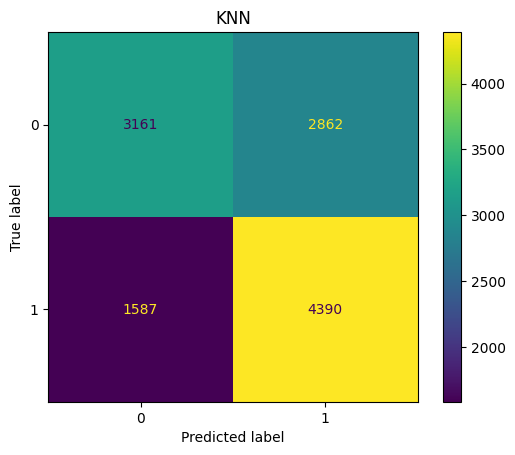

In [20]:

#first make predictions using our trained models on the test data

SVM_pred = SVM.predict(X_test)
DT_pred = DT.predict(X_test)
RF_pred = RF.predict(X_test)
KNN_pred = KNN.predict(X_test)

#Now we can generate the confusion matrices



SVM_cm = confusion_matrix(y_test, SVM_pred, labels = SVM.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = SVM_cm, display_labels = SVM.classes_)
disp.plot()
plt.title('SVM')

DT_cm = confusion_matrix(y_test, DT_pred, labels = DT.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = DT_cm, display_labels = DT.classes_)
disp.plot()
plt.title('DT')

RF_cm = confusion_matrix(y_test, RF_pred, labels = RF.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = RF_cm, display_labels = RF.classes_)
disp.plot()
plt.title('RF')

KNN_cm = confusion_matrix(y_test, KNN_pred, labels = KNN.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = KNN_cm, display_labels = KNN.classes_)
disp.plot()
plt.title('KNN')


In [21]:
#Next we will write a function that takes in the confusion matrices we generated previously and produces evaluation metrics 


In [33]:
#function to return the 
def getSpecifity(y,prediction):
    
    cm = metrics.confusion_matrix(y, prediction)

    #Extract Values
    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]
    TP = cm[1][1]

    # Specificity
    specificity = TN / (TN + FP)
    return specificity

In [36]:

print('SVM Metrics \n')

#Get Confusion Matrix

print("Specificity: %.2f" % getSpecifity(y_test, SVM_pred))
misclassification = 1 - metrics.accuracy_score(y_test, SVM_pred)
print('Misclassification Rate: %.2f' % misclassification)
print('Accuracy: %.2f' %metrics.accuracy_score(y_test, SVM_pred))
print('Precision: %.2f' %metrics.precision_score(y_test, SVM_pred))
print('Recall: %.2f' %metrics.recall_score(y_test, SVM_pred))
print('F1 Score: %.2f \n' %metrics.f1_score(y_test, SVM_pred))

print('DT Metrics \n')
print("Specificity: %.2f" % getSpecifity(y_test, DT_pred))
misclassification = 1 - metrics.accuracy_score(y_test, DT_pred)
print('Misclassification Rate: %.2f' % misclassification)
print('Accuracy: %.2f' %metrics.accuracy_score(y_test, DT_pred))
print('Precision: %.2f' %metrics.precision_score(y_test, DT_pred))
print('Recall: %.2f' %metrics.recall_score(y_test, DT_pred))
print('F1 Score: %.2f \n' %metrics.f1_score(y_test, DT_pred))

print('RF Metrics \n')
print("Specificity: %.2f" % getSpecifity(y_test, RF_pred))
misclassification = 1 - metrics.accuracy_score(y_test, RF_pred)
print('Misclassification Rate: %.2f' % misclassification)
print('Accuracy: %.2f' %metrics.accuracy_score(y_test, RF_pred))
print('Precision: %.2f' %metrics.precision_score(y_test, RF_pred))
print('Recall: %.2f' %metrics.recall_score(y_test, RF_pred))
print('F1 Score: %.2f \n' %metrics.f1_score(y_test, RF_pred))

print('KNN Metrics \n')
print("Specificity: %.2f" % getSpecifity(y_test, KNN_pred))
misclassification = 1 - metrics.accuracy_score(y_test, KNN_pred)
print('Misclassification Rate: %.2f' % misclassification)
print('Accuracy: %.2f' %metrics.accuracy_score(y_test, KNN_pred))
print('Precision: %.2f' %metrics.precision_score(y_test, KNN_pred))
print('Recall: %.2f' %metrics.recall_score(y_test, KNN_pred))
print('F1 Score: %.2f \n' %metrics.f1_score(y_test, KNN_pred))

SVM Metrics 

Specificity: 0.72
Misclassification Rate: 0.25
Accuracy: 0.75
Precision: 0.74
Recall: 0.79
F1 Score: 0.76 

DT Metrics 

Specificity: 0.69
Misclassification Rate: 0.31
Accuracy: 0.69
Precision: 0.69
Recall: 0.68
F1 Score: 0.69 

RF Metrics 

Specificity: 0.73
Misclassification Rate: 0.26
Accuracy: 0.74
Precision: 0.73
Recall: 0.74
F1 Score: 0.74 

KNN Metrics 

Specificity: 0.52
Misclassification Rate: 0.37
Accuracy: 0.63
Precision: 0.61
Recall: 0.73
F1 Score: 0.66 



############ WRITE YOUR REPORT IN THIS CELL (IF APPLICABLE) #############

The Tweets dataset contains labelled tweets for sentiment analysis. 
We cleaned the text by converting it to lowercase and removing URLs, mentions, hashtags, and punctuation. 
Stopwords were then removed from the cleaned tweets.

The processed text was converted into numerical features using CountVectorizer. 
Six classifiers were trained, and metrics such as Accuracy, Precision, Recall, F1-score, Misclassification Rate, 
and Specificity were used to evaluate and compare their performance.


SVM performed the best overall. It has the highest accuracy (0.75), F1 score (0.76), and a good balance between recall (0.79) and specificity (0.72), meaning it detects positives well without misclassifying too many negatives.

Random Forest is very close to SVM but slightly lower on most metrics.

Decision Tree performs moderately but not as strong as SVM or RF.

KNN performs the worst. Although its recall is reasonable (0.73), its specificity is very low (0.52), meaning it wrongly classifies many negative cases as positive.

Overall, SVM is the most reliable model among the four.


